# Analyse strategique des donnees — AfriMarket

**Data Analyst :** Projet d'analyse e-commerce
**Periode couverte :** Juillet 2025 - Decembre 2025 (6 mois)
**Objectif :** Produire une analyse strategique complete permettant a la direction d'AfriMarket
de prendre des decisions business sur la performance commerciale, les categories de produits,
la geographie, le marketing et les clients.

---

### Sommaire
1. [Audit & Comprehension des donnees](#1)
2. [Data Cleaning](#2)
3. [Feature Engineering](#3)
4. [Analyses](#4)
   - 4.1 Performance globale
   - 4.2 Analyse par categorie
   - 4.3 Analyse geographique
   - 4.4 Analyse marketing
   - 4.5 Analyse clients
5. [Synthese des insights cles](#5)
6. [Recommandations strategiques](#6)
7. [Conclusion business](#7)


In [1]:
# Imports et configuration generale
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

PALETTE = ["#2C5F8A", "#E07A3E", "#4C9F70", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#333333",
    "axes.grid": True, "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

def money_fmt(x, pos):
    return f"{x/1000:.0f}k"

RAW_PATH = "../data/afrimarket_dataset_senior.csv"
FIG_DIR = "../figures"


<a id="1"></a>
## 1. Audit & Comprehension des donnees

Avant toute analyse, on commence par un audit systematique du dataset brut : structure,
types, valeurs manquantes, doublons et valeurs aberrantes. Cet audit conditionne toutes
les decisions de nettoyage prises a l'etape suivante.


In [2]:
df_raw = pd.read_csv(RAW_PATH, encoding="utf-8")
print("Dimensions :", df_raw.shape)
df_raw.head()


Dimensions : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [3]:
print("=== Types de donnees ===")
print(df_raw.dtypes)


=== Types de donnees ===
id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object


In [4]:
print("=== Valeurs manquantes ===")
print(df_raw.isna().sum())


=== Valeurs manquantes ===
id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64


**Constat :** aucune valeur manquante explicite (NaN) n'est presente. En revanche, le dataset
contient des valeurs *invalides* qui jouent le meme role (prix negatifs, quantites nulles),
ce qui est plus insidieux qu'un NaN classique car cela ne remonte pas dans `isna()`.


In [5]:
print("=== Doublons ===")
print("Lignes dupliquees (toutes colonnes identiques) :", df_raw.duplicated().sum())
print("id_commande dupliques :", df_raw.duplicated(subset=['id_commande']).sum())


=== Doublons ===
Lignes dupliquees (toutes colonnes identiques) : 100
id_commande dupliques : 100


In [6]:
print("=== Incoherences categorielles ===")
for col in ["ville", "categorie", "statut_commande"]:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts())


=== Incoherences categorielles ===

--- ville ---
ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

--- categorie ---
categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64

--- statut_commande ---
statut_commande
Livrée       9080
retournée     826
Annulée       194
Name: count, dtype: int64


**Problemes de qualite detectes :**
- `ville` : *Kinshassa* est une faute d'orthographe de *Kinshasa* (605 lignes concernees).
- `categorie` : *electronique* (minuscule, sans accent) est un doublon de *Électronique* (606 lignes).
- `statut_commande` : casse incoherente — *Livrée* / *retournée* / *Annulée*.


In [7]:
print("=== Valeurs aberrantes numeriques ===")
print("prix_unitaire <= 0 :", (df_raw['prix_unitaire'] <= 0).sum(), "lignes -> min =", df_raw['prix_unitaire'].min())
print("remise < 0 :", (df_raw['remise'] < 0).sum(), "lignes -> min =", df_raw['remise'].min())
print("quantite == 0 :", (df_raw['quantite'] == 0).sum(), "lignes")
print()
print(df_raw[["prix_unitaire", "quantite", "remise", "cout_livraison", "cout_marketing"]].describe())


=== Valeurs aberrantes numeriques ===
prix_unitaire <= 0 : 632 lignes -> min = -50.0
remise < 0 : 614 lignes -> min = -0.1
quantite == 0 : 608 lignes



       prix_unitaire      quantite        remise  cout_livraison  cout_marketing
count   10100.000000  10100.000000  10100.000000    10100.000000    10100.000000
mean      140.493353      1.866040      0.111422        6.008478        7.388465
std       172.031607      0.920966      0.098352        2.304953        4.638945
min       -50.000000      0.000000     -0.100000        2.000000        0.500000
25%        28.057500      1.000000      0.050000        4.040000        3.980000
50%        52.975000      2.000000      0.090000        5.990000        6.870000
75%       201.885000      3.000000      0.190000        8.030000       10.850000
max       915.860000      3.000000      0.300000       10.000000       19.980000


**Resume de l'audit :**

| Probleme | Volume | Decision de traitement |
|---|---|---|
| Doublons exacts (id_commande) | 100 lignes | Suppression |
| Prix unitaire invalide (<=0, souvent -50) | 622 lignes | Imputation par la mediane de la categorie |
| Remise negative (-0.10) | 600 lignes | Valeur absolue (erreur de signe probable) |
| Quantite nulle | 600 lignes | Suppression (commande sans unite = non exploitable) |
| Ville mal orthographiee (Kinshassa) | 605 lignes | Correction -> Kinshasa |
| Categorie incoherente (electronique) | 606 lignes | Fusion -> Électronique |
| Statut avec casse incoherente | tout le dataset | Capitalisation uniforme |

Les dates (`date_commande`) sont deja au format ISO `YYYY-MM-DD` et ne necessitent qu'un
typage en `datetime`, sans correction de fond.


<a id="2"></a>
## 2. Data Cleaning

On applique ici, dans l'ordre, chaque correction identifiee lors de l'audit pour produire
le dataset propre `df_clean`.


In [8]:
df_clean = df_raw.copy()
n_start = len(df_clean)

# --- 2.1 Doublons exacts ---
n_dup = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()

# --- 2.2 Standardisation des dates ---
df_clean["date_commande"] = pd.to_datetime(df_clean["date_commande"], format="%Y-%m-%d", errors="coerce")

# --- 2.3 Villes mal orthographiees ---
df_clean["ville"] = df_clean["ville"].replace({"Kinshassa": "Kinshasa"}).str.strip()

# --- 2.4 Categories incoherentes ---
df_clean["categorie"] = df_clean["categorie"].replace({"electronique": "Électronique"}).str.strip()

# --- 2.5 Statuts : casse uniforme ---
df_clean["statut_commande"] = df_clean["statut_commande"].str.strip().str.capitalize()

# --- 2.6 Remises negatives : erreur de signe -> valeur absolue, bornee a la plage metier [0, 0.30] ---
n_remise_neg = (df_clean["remise"] < 0).sum()
df_clean["remise"] = df_clean["remise"].abs().clip(lower=0, upper=0.30)

# --- 2.7 Prix aberrants (<=0) : imputation par la mediane de la categorie ---
n_prix_invalid = (df_clean["prix_unitaire"] <= 0).sum()
df_clean.loc[df_clean["prix_unitaire"] <= 0, "prix_unitaire"] = np.nan
median_prix_cat = df_clean.groupby("categorie")["prix_unitaire"].transform("median")
df_clean["prix_unitaire"] = df_clean["prix_unitaire"].fillna(median_prix_cat)

# --- 2.8 Quantites nulles : commande non exploitable -> suppression ---
n_qty_zero = (df_clean["quantite"] == 0).sum()
df_clean = df_clean[df_clean["quantite"] > 0].copy()

df_clean["id_commande"] = df_clean["id_commande"].astype(str)
df_clean["id_client"] = df_clean["id_client"].astype(str)

n_end = len(df_clean)

print("=== RAPPORT DE NETTOYAGE ===")
print(f"Lignes de depart             : {n_start}")
print(f"Doublons exacts supprimes    : {n_dup}")
print(f"Remises negatives corrigees  : {n_remise_neg}")
print(f"Prix invalides imputes       : {n_prix_invalid}")
print(f"Quantites nulles supprimees  : {n_qty_zero}")
print(f"Lignes finales (df_clean)    : {n_end}  ({n_start - n_end} lignes supprimees au total)")


=== RAPPORT DE NETTOYAGE ===
Lignes de depart             : 10100
Doublons exacts supprimes    : 100
Remises negatives corrigees  : 600
Prix invalides imputes       : 622
Quantites nulles supprimees  : 600
Lignes finales (df_clean)    : 9400  (700 lignes supprimees au total)


In [9]:
# Verification post-nettoyage
print("Villes :", sorted(df_clean['ville'].unique()))
print("Categories :", sorted(df_clean['categorie'].unique()))
print("Statuts :", sorted(df_clean['statut_commande'].unique()))
df_clean.describe()


Villes : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']
Categories : ['Beauté', 'Maison', 'Mode', 'Électronique']
Statuts : ['Annulée', 'Livrée', 'Retournée']


,date_commande,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,9400,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000
mean,2025-10-02 01:38:39.319149,153.417774,1.986383,0.123604,6.004995,7.394121
min,2025-07-01 00:00:00,0.330000,1.000000,0.000000,2.000000,0.500000
25%,2025-08-17 00:00:00,31.680000,1.000000,0.060000,4.030000,4.000000
50%,2025-10-03 00:00:00,58.930000,2.000000,0.100000,6.000000,6.860000
75%,2025-11-18 00:00:00,249.010000,3.000000,0.190000,8.030000,10.852500
max,2025-12-31 00:00:00,915.860000,3.000000,0.300000,10.000000,19.980000
std,NaN,169.195243,0.815340,0.082515,2.303562,4.637290


<a id="3"></a>
## 3. Feature Engineering

On enrichit `df_clean` avec les variables necessaires aux analyses business.

**Hypothese de marge brute par categorie** (le dataset ne contient pas de cout d'achat) :
on applique un taux de marge typique du secteur e-commerce, plus faible sur l'electronique
(marche tres concurrentiel sur les prix) et plus confortable sur la mode/beaute/maison.

| Categorie | Taux de marge brute suppose |
|---|---|
| Électronique | 15% |
| Mode | 45% |
| Beauté | 50% |
| Maison | 35% |


In [10]:
df_features = df_clean.copy()

TAUX_MARGE = {"Électronique": 0.15, "Mode": 0.45, "Beauté": 0.50, "Maison": 0.35}

# chiffre_affaires : revenu net de la remise
df_features["chiffre_affaires"] = df_features["prix_unitaire"] * df_features["quantite"] * (1 - df_features["remise"])

# marge_brute estimee
df_features["taux_marge"] = df_features["categorie"].map(TAUX_MARGE)
df_features["marge_brute"] = df_features["chiffre_affaires"] * df_features["taux_marge"]

# profit_net estime = marge brute - couts logistiques - couts marketing
df_features["profit_net"] = df_features["marge_brute"] - df_features["cout_livraison"] - df_features["cout_marketing"]

# mois de la commande
df_features["mois"] = df_features["date_commande"].dt.to_period("M").astype(str)

# indicateurs de statut
df_features["indicateur_retour"] = (df_features["statut_commande"] == "Retournée").astype(int)
df_features["indicateur_annulation"] = (df_features["statut_commande"] == "Annulée").astype(int)

# nombre de commandes par client (frequence d'achat sur la periode)
df_features["nombre_commandes_par_client"] = df_features.groupby("id_client")["id_commande"].transform("count")

# valeur_vie_client (CLV simplifiee) : CA reel cumule genere par le client (hors commandes annulees)
ca_reel = df_features.loc[df_features["statut_commande"] != "Annulée"].groupby("id_client")["chiffre_affaires"].sum()
df_features["valeur_vie_client"] = df_features["id_client"].map(ca_reel).fillna(0)

print("df_features :", df_features.shape)
df_features[["chiffre_affaires","marge_brute","profit_net","mois",
             "indicateur_retour","nombre_commandes_par_client","valeur_vie_client"]].describe()


df_features :

 (9400, 23)


,chiffre_affaires,marge_brute,profit_net,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
count,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000,9400.000000
mean,272.022799,57.906350,44.507234,0.081383,12.383191,3314.868264
std,347.957479,50.862841,51.289262,0.273437,7.268048,2303.671559
min,0.900900,0.405405,-24.935560,0.000000,1.000000,0.000000
25%,48.385625,20.975092,7.625900,0.000000,4.000000,1236.656300
50%,103.216650,40.534350,27.653613,0.000000,14.000000,3322.982500
75%,357.327900,78.616815,65.811487,0.000000,18.000000,4780.540400
max,2315.085300,347.262795,339.332795,1.000000,29.000000,11553.739200


In [11]:
# On sauvegarde le dataset complet (toutes commandes, y compris annulees) : c'est la base
# utilisee par le dashboard Streamlit. Pour le calcul du CA/marge/profit, on travaille en
# revanche sur df_valid, qui exclut les commandes annulees (aucun revenu reel encaisse).
df_valid = df_features[df_features["statut_commande"] != "Annulée"].copy()
df_features.to_csv("../data/df_features.csv", index=False, encoding="utf-8")
print("Dataset final sauvegarde : df_features.csv —", df_features.shape, "| valides (hors annulations) :", df_valid.shape)


Dataset final sauvegarde : df_features.csv — (9400, 23) | valides (hors annulations) : (9217, 23)


<a id="4"></a>
## 4. Analyses demandees

### 4.1. Performance globale

In [12]:
ca_total = df_valid["chiffre_affaires"].sum()
ca_net_hors_retours = df_valid.loc[df_valid["statut_commande"] != "Retournée", "chiffre_affaires"].sum()
profit_net_total = df_valid["profit_net"].sum()
panier_moyen = df_valid["chiffre_affaires"].mean()
taux_annulation = (df_features["statut_commande"] == "Annulée").mean() * 100
taux_retour = (df_features["statut_commande"] == "Retournée").mean() * 100

kpis = pd.DataFrame({
    "KPI": ["CA total (brut)", "CA net (hors retours)", "Profit net estime", "Panier moyen",
            "Taux d'annulation", "Taux de retour"],
    "Valeur": [f"{ca_total:,.0f} $", f"{ca_net_hors_retours:,.0f} $", f"{profit_net_total:,.0f} $",
               f"{panier_moyen:,.2f} $", f"{taux_annulation:.2f} %", f"{taux_retour:.2f} %"]
})
kpis


,KPI,Valeur
0,CA total (brut),"2,507,325 $"
1,CA net (hors retours),"2,188,830 $"
2,Profit net estime,"409,924 $"
3,Panier moyen,272.03 $
4,Taux d'annulation,1.95 %
5,Taux de retour,8.14 %


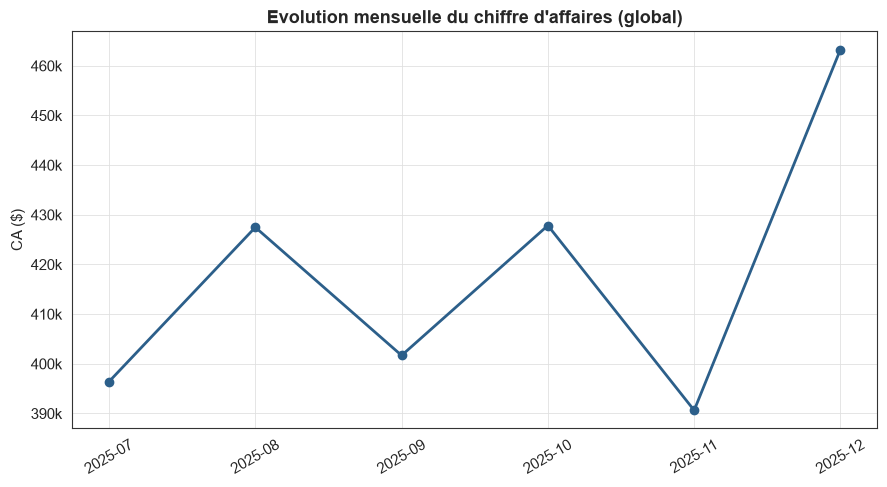

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
evo = df_valid.groupby("mois")["chiffre_affaires"].sum()
ax.plot(evo.index, evo.values, marker="o", color=PALETTE[0], linewidth=2)
ax.set_title("Evolution mensuelle du chiffre d'affaires (global)")
ax.set_ylabel("CA ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.xticks(rotation=30)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_evolution_ca_mensuel.png", dpi=150)
plt.show()


**Lecture :** le CA mensuel oscille entre ~410k$ et ~460k$ sans tendance de croissance nette
sur les 6 mois — coherent avec le constat de la direction (« variations importantes du CA »).
Le detail par categorie ci-dessous permet d'expliquer ces variations.


### 4.2. Analyse par categorie

**Question strategique : quelle categorie doit etre priorisee ou optimisee ?**


In [14]:
cat_stats = df_valid.groupby("categorie").agg(
    CA=("chiffre_affaires", "sum"), marge=("marge_brute", "sum"),
    profit=("profit_net", "sum"), nb_commandes=("id_commande", "count"),
).round(2)
cat_stats["CA_%"] = (cat_stats["CA"] / cat_stats["CA"].sum() * 100).round(1)
cat_stats["taux_retour_%"] = (df_features.groupby("categorie")["indicateur_retour"].mean() * 100).round(2)
cat_stats.sort_values("CA", ascending=False)


,CA,marge,profit,nb_commandes,CA_%,taux_retour_%
categorie,,,,,,
Électronique,1870409.97,280561.50,241183.30,2950,74.6,13.84
Maison,374500.52,131075.18,107506.71,1758,14.9,4.95
Mode,186024.47,83711.01,46451.38,2783,7.4,7.44
Beauté,76390.23,38195.12,14782.84,1726,3.0,2.79


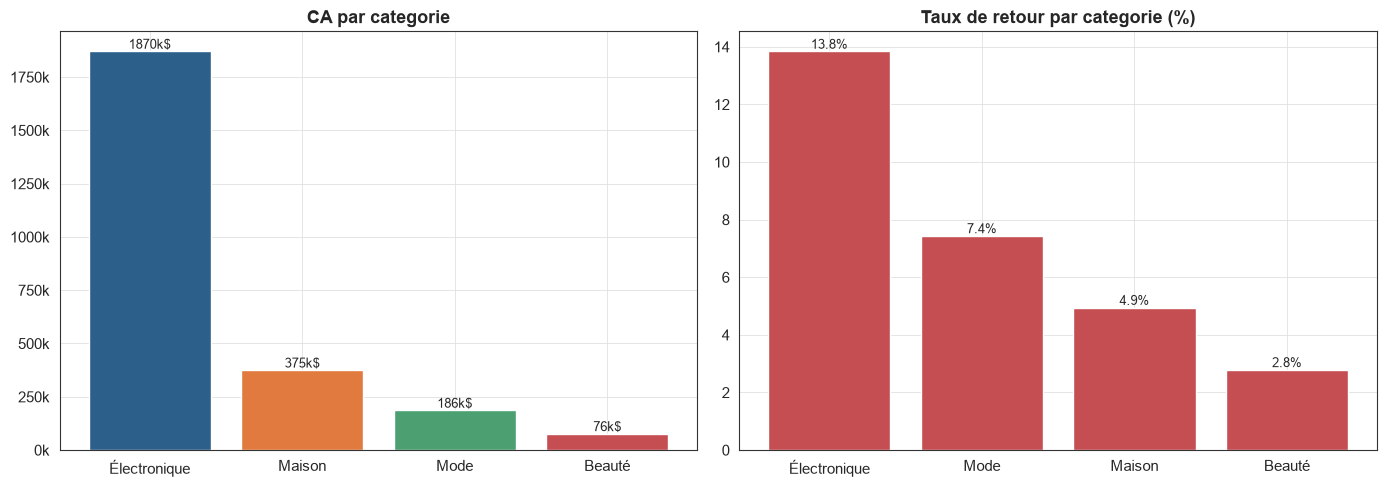

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_ca = cat_stats["CA"].sort_values(ascending=False)
bars = axes[0].bar(cat_ca.index, cat_ca.values, color=PALETTE[:len(cat_ca)])
axes[0].set_title("CA par categorie")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
for b in bars:
    axes[0].annotate(f"{b.get_height()/1000:.0f}k$", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom", fontsize=9)

retour_cat = (df_features.groupby("categorie")["indicateur_retour"].mean() * 100).sort_values(ascending=False)
bars2 = axes[1].bar(retour_cat.index, retour_cat.values, color=PALETTE[3])
axes[1].set_title("Taux de retour par categorie (%)")
for b in bars2:
    axes[1].annotate(f"{b.get_height():.1f}%", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_03_ca_retour_categorie.png", dpi=150)
plt.show()


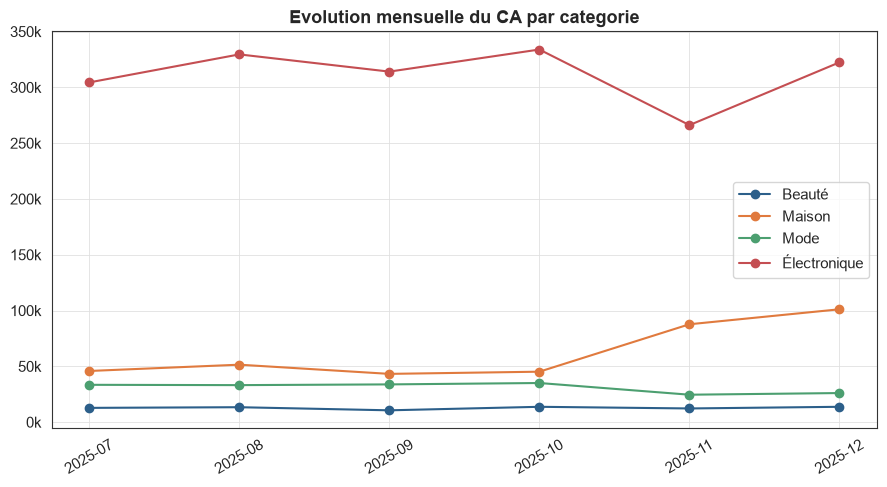

In [16]:
evo_cat = df_valid.groupby(["mois", "categorie"])["chiffre_affaires"].sum().unstack()
fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(evo_cat.columns):
    ax.plot(evo_cat.index, evo_cat[col], marker="o", label=col, color=PALETTE[i % len(PALETTE)])
ax.set_title("Evolution mensuelle du CA par categorie")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.legend()
plt.xticks(rotation=30)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_evolution_ca_categorie.png", dpi=150)
plt.show()


**Reponse a la question strategique :**
*Électronique* genere **74.6% du CA total** mais affiche le **taux de retour le plus eleve (13.8%)**
et la **marge la plus faible (15%)** — c'est la categorie a **optimiser en priorite** (qualite produit /
selection fournisseurs pour faire baisser les retours, qui rognent directement le profit).
A l'inverse, *Beauté* et *Mode* ont des marges elevees (45-50%) et des taux de retour faibles
(<7.5%) mais un poids commercial encore marginal (3% et 7.4% du CA) : ce sont les categories a
**prioriser pour la croissance**, car chaque dollar de CA supplementaire y est nettement plus
rentable que sur l'electronique.


### 4.3. Analyse geographique

**Question strategique : ou devons-nous investir davantage ?**


In [17]:
ville_stats = df_valid.groupby("ville").agg(
    CA=("chiffre_affaires", "sum"), profit=("profit_net", "sum"), nb_commandes=("id_commande", "count"),
).round(2)
ville_stats["taux_annulation_%"] = (df_features.groupby("ville")["indicateur_annulation"].mean() * 100).round(2)
ville_stats.sort_values("CA", ascending=False)


,CA,profit,nb_commandes,taux_annulation_%
ville,,,,
Kinshasa,752095.70,122949.95,2717,0.26
Abidjan,500916.33,81044.64,1756,0.00
Dakar,348707.40,57824.85,1346,0.00
Douala,331903.31,54199.58,1186,12.92
Lomé,184253.82,30348.04,682,0.00
Cotonou,159153.76,26356.98,631,0.00
Libreville,124149.33,20209.52,467,0.00
Brazzaville,106145.54,16990.66,432,0.00


In [18]:
evo_ville = df_valid.groupby(["mois", "ville"])["chiffre_affaires"].sum().unstack()
premier_mois, dernier_mois = evo_ville.index.min(), evo_ville.index.max()
croissance = ((evo_ville.loc[dernier_mois] - evo_ville.loc[premier_mois]) / evo_ville.loc[premier_mois] * 100).round(1)
croissance = croissance.sort_values(ascending=False)
print(f"Croissance du CA {premier_mois} -> {dernier_mois} (%) :")
croissance


Croissance du CA 2025-07 -> 2025-12 (%) :


ville
Douala         76.3
Brazzaville    60.1
Abidjan        22.4
Kinshasa       20.7
Lomé           11.1
Cotonou         4.1
Dakar         -11.6
Libreville    -46.3
dtype: float64

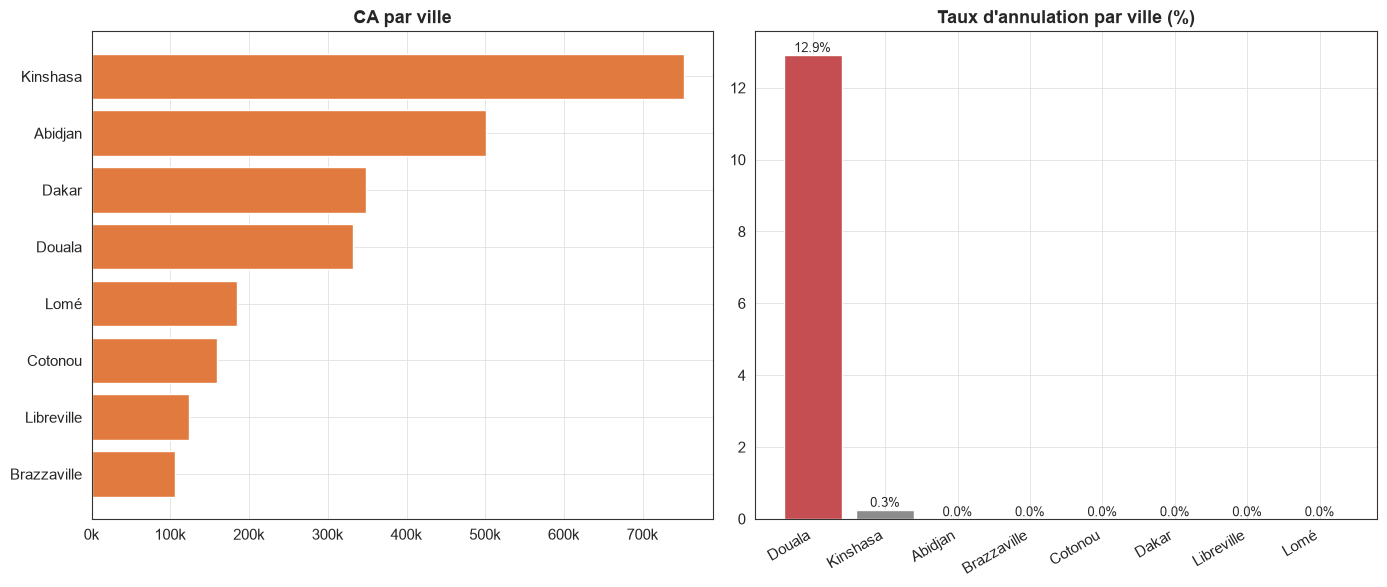

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ville_ca = ville_stats["CA"].sort_values()
axes[0].barh(ville_ca.index, ville_ca.values, color=PALETTE[1])
axes[0].set_title("CA par ville")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

annul_ville = ville_stats["taux_annulation_%"].sort_values(ascending=False)
colors = [PALETTE[3] if v == annul_ville.max() else PALETTE[7] for v in annul_ville.values]
bars = axes[1].bar(annul_ville.index, annul_ville.values, color=colors)
axes[1].set_title("Taux d'annulation par ville (%)")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
for b in bars:
    axes[1].annotate(f"{b.get_height():.1f}%", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_07_ca_annulation_ville.png", dpi=150)
plt.show()


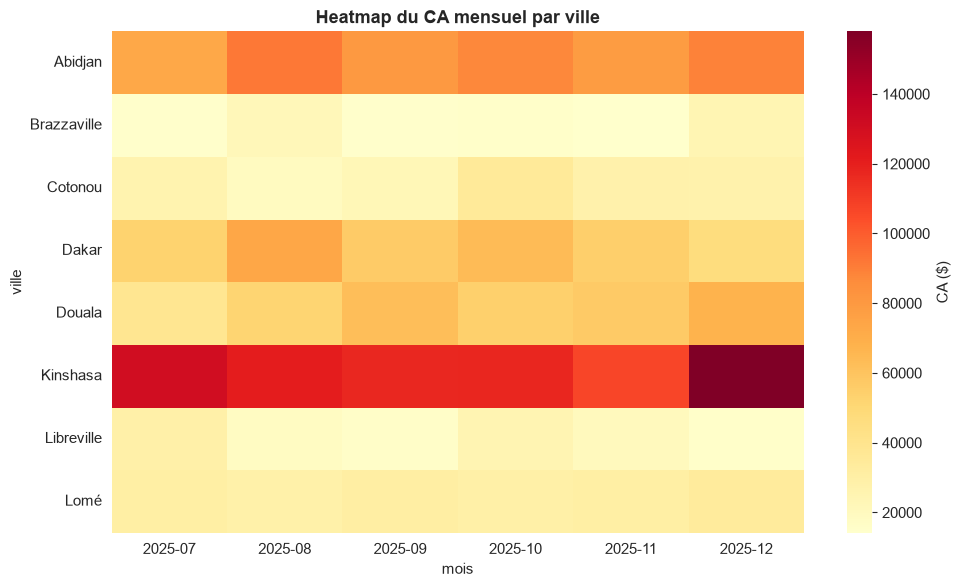

In [20]:
heat = df_valid.groupby(["ville", "mois"])["chiffre_affaires"].sum().unstack().fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, cmap="YlOrRd", annot=False, ax=ax, cbar_kws={"label": "CA ($)"})
ax.set_title("Heatmap du CA mensuel par ville")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_heatmap_ca_ville_mois.png", dpi=150)
plt.show()


**Reponse a la question strategique :**
*Kinshasa* (32% du CA), *Abidjan* et *Dakar* sont les 3 marches les plus solides — a consolider.
Mais ce sont *Douala* (+76% de croissance sur la periode) et *Brazzaville* (+60%) qui montrent la
**dynamique de croissance la plus forte** : ce sont les marches ou investir davantage (marketing,
stock) pour capter la traction en cours. Point d'alerte : *Douala* cumule cette forte croissance
avec un **taux d'annulation de 12.9%**, largement au-dessus des autres villes (0-1%) — signe probable
d'un probleme operationnel local (paiement, livraison) qu'il faut corriger avant d'investir davantage,
sous peine de perdre les clients acquis. *Libreville* recule (-46%) et merite un diagnostic dedie.


### 4.4. Analyse marketing

**Question strategique : quel canal merite plus de budget ? Lequel doit etre optimise ou reduit ?**

Formule : `ROI = (Revenus - Cout marketing) / Cout marketing`


In [21]:
mkt_stats = df_valid.groupby("canal_marketing").agg(
    CA=("chiffre_affaires", "sum"), cout_marketing=("cout_marketing", "sum"), nb_commandes=("id_commande", "count"),
).round(2)
mkt_stats["ROI"] = ((mkt_stats["CA"] - mkt_stats["cout_marketing"]) / mkt_stats["cout_marketing"]).round(2)
client_canal = df_features.groupby(["id_client", "canal_marketing"])["id_commande"].count().reset_index()
retention = client_canal.groupby("canal_marketing")["id_commande"].apply(lambda x: (x > 1).mean() * 100).round(2)
mkt_stats["taux_retention_%"] = retention
mkt_stats.sort_values("ROI", ascending=False)


,CA,cout_marketing,nb_commandes,ROI,taux_retention_%
canal_marketing,,,,,
Email,532086.85,2296.67,1852,230.68,46.29
Google Ads,664891.03,12935.32,2351,50.40,50.25
Instagram Ads,949839.29,37032.07,3699,24.65,54.19
Influenceur,360508.03,15984.23,1315,21.55,42.38


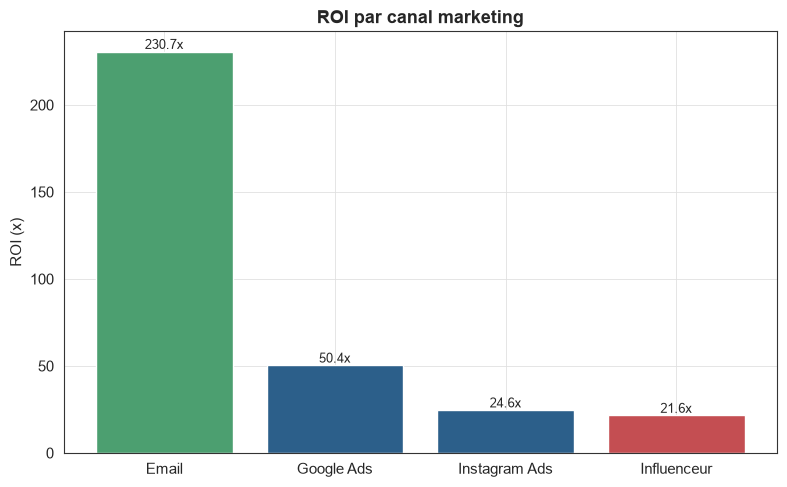

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
mkt_sorted = mkt_stats.sort_values("ROI", ascending=False)
colors = [PALETTE[2] if v == mkt_sorted["ROI"].max() else (PALETTE[3] if v == mkt_sorted["ROI"].min() else PALETTE[0]) for v in mkt_sorted["ROI"]]
bars = ax.bar(mkt_sorted.index, mkt_sorted["ROI"], color=colors)
ax.set_title("ROI par canal marketing")
ax.set_ylabel("ROI (x)")
for b in bars:
    ax.annotate(f"{b.get_height():.1f}x", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_roi_canal_marketing.png", dpi=150)
plt.show()


**Reponse a la question strategique :**
*Email* a de loin le **meilleur ROI (231x)** pour un budget marginal (2.3k$ sur 6 mois) — canal
**sous-investi**, a scaler en priorite (le cout marginal d'un envoi supplementaire est quasi nul).
*Instagram Ads* genere le plus de CA et la meilleure retention (54%) mais avec un ROI plus faible
(24.7x) du fait d'un budget deja consequent (37k$) : canal a **maintenir**, mais a surveiller pour
eviter les rendements decroissants. *Influenceur* cumule le **ROI le plus faible (21.6x)** et la
**retention la plus faible (42%)** : c'est le canal a **optimiser ou reduire** en premier.


### 4.5. Analyse clients

**Question strategique : comment ameliorer la retention ?**


In [23]:
nb_clients = df_features["id_client"].nunique()
commandes_par_client = df_features.groupby("id_client")["id_commande"].count()
pct_recurrents = (commandes_par_client > 1).mean() * 100
print(f"Nombre total de clients        : {nb_clients}")
print(f"%% clients recurrents (>1 cmd)  : {pct_recurrents:.2f}%")


Nombre total de clients        : 1747
%% clients recurrents (>1 cmd)  : 74.01%


In [24]:
clv = df_valid.groupby("id_client")["chiffre_affaires"].sum().sort_values(ascending=False)
clv_cum_pct = clv.cumsum() / clv.sum() * 100
nb_clients_80 = (clv_cum_pct <= 80).sum() + 1
print(f"Clients generant 80%% du CA : {nb_clients_80} ({nb_clients_80/len(clv)*100:.1f}% de la base)")
print()
print("Top 10 clients (CA cumule) :")
clv.head(10)


Clients generant 80%% du CA : 553 (31.9% de la base)

Top 10 clients (CA cumule) :


id_client
C0157    11553.7392
C0266    10673.2270
C0120     9514.3431
C0003     9473.0849
C0051     9419.4902
C0379     8995.6496
C0114     8915.4355
C0184     8476.5419
C0067     8476.4071
C0364     8252.4673
Name: chiffre_affaires, dtype: float64

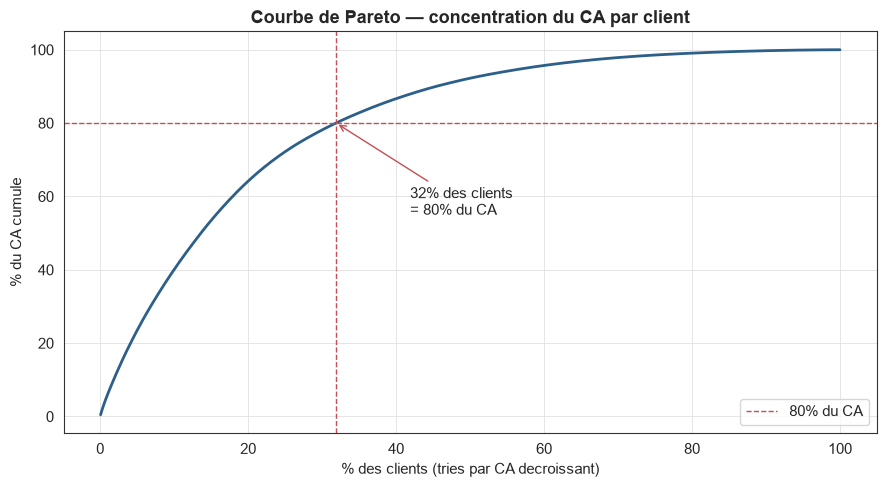

In [25]:
clv_sorted = clv.reset_index(drop=True)
clv_cum_pct2 = clv_sorted.cumsum() / clv_sorted.sum() * 100
pct_clients = np.arange(1, len(clv_sorted)+1) / len(clv_sorted) * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(pct_clients, clv_cum_pct2.values, color=PALETTE[0], linewidth=2)
ax1.axhline(80, color=PALETTE[3], linestyle="--", linewidth=1, label="80% du CA")
idx_80 = (clv_cum_pct2 <= 80).sum()
x80 = pct_clients[idx_80]
ax1.axvline(x80, color=PALETTE[3], linestyle="--", linewidth=1)
ax1.annotate(f"{x80:.0f}% des clients\n= 80% du CA", xy=(x80, 80), xytext=(x80+10, 55),
             arrowprops=dict(arrowstyle="->", color=PALETTE[3]))
ax1.set_title("Courbe de Pareto — concentration du CA par client")
ax1.set_xlabel("% des clients (tries par CA decroissant)")
ax1.set_ylabel("% du CA cumule")
ax1.legend(loc="lower right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_pareto_clients.png", dpi=150)
plt.show()


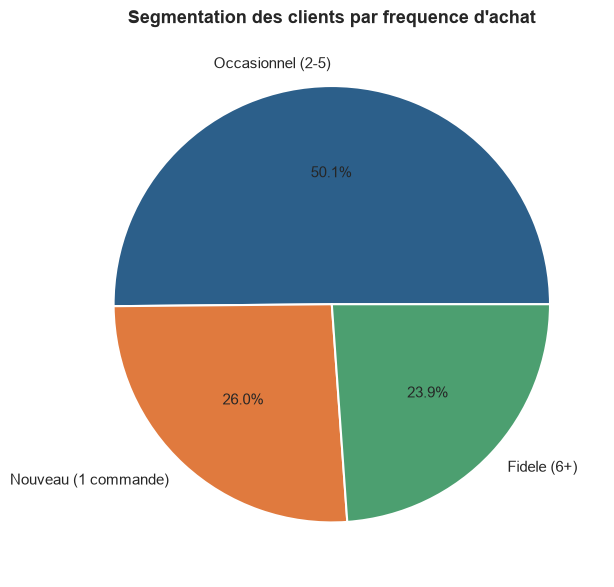

id_commande
Occasionnel (2-5)       876
Nouveau (1 commande)    454
Fidele (6+)             417
Name: count, dtype: int64

In [26]:
def segment(n):
    if n == 1: return "Nouveau (1 commande)"
    elif n <= 5: return "Occasionnel (2-5)"
    else: return "Fidele (6+)"

seg = commandes_par_client.apply(segment).value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(seg.values, labels=seg.index, autopct="%1.1f%%", colors=PALETTE[:len(seg)],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Segmentation des clients par frequence d'achat")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_segmentation_clients.png", dpi=150)
plt.show()
seg


**Reponse a la question strategique :**
74% des clients sont deja recurrents (au moins 2 commandes) — la base est globalement fidele.
Le CA reste toutefois concentre : **32% des clients generent 80% du CA**. Avec 26% de clients
« nouveaux » a une seule commande, le principal levier de retention est de **convertir ce segment
en acheteurs recurrents** (ex : campagne de reactivation email a J+30, qui est justement le canal
au meilleur ROI identifie en 4.4), plutot que d'acquerir de nouveaux clients a tout prix.


<a id="5"></a>
## 5. Synthese des insights cles

1. **Électronique** = 74.6% du CA mais marge la plus faible (15%) et taux de retour le plus eleve (13.8%).
2. **Douala** connait la plus forte croissance (+76%) mais aussi le plus fort taux d'annulation (12.9%) — un probleme operationnel local freine potentiellement la croissance.
3. **Email** est le canal le plus rentable (ROI 231x) mais reste largement sous-finance face a Instagram Ads.
4. **32% des clients** generent 80% du CA — la base est fidele (74% de clients recurrents) mais le segment "nouveaux clients" (26%) est mal converti en recurrence.
5. Le **profit net global estime** (~410k$ sur 6 mois) reste nettement inferieur au potentiel du CA brut (~2.51M$), du fait de la marge structurellement faible de l'electronique.


<a id="6"></a>
## 6. Recommandations strategiques

**1. Reduire le taux de retour sur l'Électronique (13.8%)**
Auditer la qualite produit et la fiche descriptive (specifications, photos) des references
electronique les plus retournees ; renforcer le controle qualite fournisseur. Un retour
economise sur cette categorie a fort volume a un effet demultiplie sur le profit net.

**2. Investiguer et corriger le probleme operationnel a Douala**
Avant d'accroitre l'investissement marketing sur ce marche en forte croissance (+76%),
diagnostiquer la cause du taux d'annulation de 12.9% (paiement mobile ? delais de livraison ?)
pour ne pas acquerir des clients qui annulent immediatement.

**3. Reallouer le budget marketing vers l'Email et reduire l'Influenceur**
Multiplier le budget Email (ROI 231x, budget actuel marginal de 2.3k$) via une segmentation
plus fine des campagnes ; reduire ou renegocier les partenariats Influenceur (ROI le plus
faible : 21.6x, retention la plus faible : 42%).

**4. Lancer un programme de reactivation des clients "1 commande" (26% de la base)**
Cibler ce segment avec une campagne Email de relance a J+30 (canal au meilleur ROI) incluant
une offre sur Mode/Beaute (categories a marge elevee) pour transformer un one-shot en client
recurrent, sans diluer la marge sur l'electronique.

**5. Prioriser la croissance sur Mode et Beaute plutot que sur l'Electronique**
Ces deux categories combinent marge elevee (45-50%) et taux de retour faible (<7.5%) mais
ne representent que 10.4% du CA cumule : chaque dollar de budget marketing ou de stock
supplementaire y genere un profit net proportionnellement plus eleve que sur l'electronique.


<a id="7"></a>
## 7. Conclusion business orientee action

AfriMarket degage un chiffre d'affaires solide (2.51M$ sur 6 mois) mais sa rentabilite est
structurellement bridee par la dependance a l'Électronique, categorie a fort volume mais a
faible marge et fort taux de retour. La **priorite immediate** n'est pas de generer plus de CA,
mais de **proteger et augmenter le profit net** en (1) reduisant les retours electronique,
(2) resolvant le probleme operationnel de Douala avant d'y investir davantage, et
(3) reallouant une partie du budget marketing d'Influenceur vers l'Email et vers les
categories a marge elevee (Mode, Beaute). La base clients, deja fidele a 74%, offre un levier
de croissance rentable via la reactivation cible des acheteurs a commande unique — une strategie
moins couteuse et plus rentable qu'une acquisition massive de nouveaux clients.
